In [ ]:
# Exploratory Data Analysis — Data Explorers 2025
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Load tất cả bảng
df       = pd.read_csv('dulieubanhang.csv', encoding='utf-8-sig')
kh       = pd.read_csv('khachhang.csv',     encoding='utf-8-sig')
sp       = pd.read_csv('sanpham.csv',        encoding='utf-8-sig')
nv       = pd.read_csv('nhanvien.csv',       encoding='utf-8-sig')
cn       = pd.read_csv('chinhanh.csv',       encoding='utf-8-sig')
kpi      = pd.read_csv('KPI.csv',            encoding='utf-8-sig')

# Chuẩn hóa tên cột và định dạng ngày tháng
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Ngày hạch toán': 'Ngày_hạch_toán',
    'Mã KH': 'Mã_KH',
    'Mã Sản Phẩm': 'Mã_Sản_Phẩm',
    'Số lượng bán': 'Số_lượng_bán',
    'Đơn giá': 'Đơn_giá',
    'Doanh thu': 'Doanh_thu',
    'Giá vốn hàng hóa': 'Giá_vốn',
    'Mã nhân viên bán': 'Mã_NV',
    'Chi nhánh': 'Chi_nhánh',
})
df['Ngày_hạch_toán'] = pd.to_datetime(df['Ngày_hạch_toán'])
df['Tháng'] = df['Ngày_hạch_toán'].dt.to_period('M')

# Merge thêm nhóm sản phẩm
sp = sp.rename(columns={'Mã Sản phẩm': 'Mã_Sản_Phẩm', 'Nhóm sản phẩm': 'Nhóm_SP'})
df = df.merge(sp[['Mã_Sản_Phẩm', 'Nhóm_SP']], on='Mã_Sản_Phẩm', how='left')

print('Shape:', df.shape)
df.head()

Shape: (10000, 12)


,Ngày_hạch_toán,Đơn hàng,Mã_KH,Mã_Sản_Phẩm,Số_lượng_bán,Đơn_giá,Doanh_thu,Giá_vốn,Mã_NV,Chi_nhánh,Tháng,Nhóm_SP
0,2024-01-01,ĐH3381365,KH-0052,P-396,10,1215000,12150000,8100000,NV190,CN HN,2024-01,Phụ kiện
1,2024-01-01,ĐH8038262,KH-0257,P-545,5,11655000,58275000,38850000,NV164,CN DN,2024-01,Máy tính
2,2024-01-01,ĐH9049637,KH-0727,P-072,7,165000,1155000,770000,NV192,CN DN,2024-01,Phần mềm
3,2024-01-01,ĐH1602374,KH-0716,P-530,3,28980000,86940000,57960000,NV233,CN HN,2024-01,Phụ kiện
4,2024-01-01,ĐH8875469,KH-0210,P-204,5,42120000,210600000,140400000,NV089,CN DN,2024-01,Phần mềm


In [5]:
df.dtypes

Ngày_hạch_toán    datetime64[us]
Đơn hàng                     str
Mã_KH                        str
Mã_Sản_Phẩm                  str
Số_lượng_bán               int64
Đơn_giá                    int64
Doanh_thu                  int64
Giá_vốn                    int64
Mã_NV                        str
Chi_nhánh                    str
Tháng                  period[M]
Nhóm_SP                      str
dtype: object

In [6]:
df_clean = df[df['Doanh_thu'] > 0].copy()

fmt = lambda x: f'{x:,.0f}'

# --- Thống kê các cột số ---
print('=== Thống kê mô tả các biến số ===')
display(df_clean[['Số_lượng_bán', 'Đơn_giá', 'Doanh_thu', 'Giá_vốn']].describe().map(fmt))

# --- Thống kê theo nhóm sản phẩm ---
print('\n=== Thống kê doanh thu theo Nhóm sản phẩm ===')
group_desc = df_clean.groupby('Nhóm_SP')['Doanh_thu'].agg(
    Số_giao_dịch   = 'count',
    Tổng           = 'sum',
    Trung_bình     = 'mean',
    Trung_vị       = 'median',
    Nhỏ_nhất       = 'min',
    Lớn_nhất       = 'max',
    Độ_lệch_chuẩn = 'std'
)
display(group_desc.map(fmt))

# --- Thống kê theo chi nhánh ---
print('\n=== Thống kê doanh thu theo Chi nhánh ===')
branch_desc = df_clean.groupby('Chi_nhánh')['Doanh_thu'].agg(
    Số_giao_dịch = 'count',
    Tổng         = 'sum',
    Trung_bình   = 'mean',
    Trung_vị     = 'median',
    Lớn_nhất     = 'max',
)
display(branch_desc.map(fmt))

# --- Thống kê khách hàng ---
print('\n=== Thống kê theo khách hàng ===')
kh_stats = df_clean.groupby('Mã_KH').agg(
    Tổng_doanh_thu = ('Doanh_thu', 'sum'),
    Số_đơn         = ('Đơn hàng', 'nunique'),
    Số_giao_dịch   = ('Doanh_thu', 'count'),
)
display(kh_stats.describe().map(lambda x: f'{x:,.1f}'))

=== Thống kê mô tả các biến số ===


,Số_lượng_bán,Đơn_giá,Doanh_thu,Giá_vốn
count,"9,810","9,810","9,810","9,810"
mean,6,"18,940,933","105,416,703","70,277,802"
std,3,"51,269,525","323,702,763","215,801,842"
min,1,"30,000","30,000","20,000"
25%,3,"1,335,000","5,497,500","3,665,000"
50%,6,"5,220,000","23,212,500","15,475,000"
75%,8,"15,915,000","79,350,000","52,900,000"
max,10,"684,450,000","6,844,500,000","4,563,000,000"



=== Thống kê doanh thu theo Nhóm sản phẩm ===


,Số_giao_dịch,Tổng,Trung_bình,Trung_vị,Nhỏ_nhất,Lớn_nhất,Độ_lệch_chuẩn
Nhóm_SP,,,,,,,
Dịch vụ,44,"20,541,015,000","466,841,250","286,080,000","1,755,000","2,349,750,000","597,477,733"
Máy tính,520,"153,592,230,000","295,369,673","83,812,500","5,970,000","3,422,250,000","595,302,907"
Phần mềm,"6,850","570,992,340,000","83,356,546","26,820,000","45,000","3,289,950,000","191,750,082"
Phụ kiện,"2,396","289,012,275,000","120,622,819","10,500,000","30,000","6,844,500,000","478,481,569"



=== Thống kê doanh thu theo Chi nhánh ===


,Số_giao_dịch,Tổng,Trung_bình,Trung_vị,Lớn_nhất
Chi_nhánh,,,,,
CN DN,"3,326","341,079,255,000","102,549,385","22,972,500","6,160,050,000"
CN HCM,"3,226","351,749,820,000","109,035,902","22,665,000","6,844,500,000"
CN HN,"3,258","341,308,785,000","104,760,216","23,670,000","6,844,500,000"



=== Thống kê theo khách hàng ===


,Tổng_doanh_thu,Số_đơn,Số_giao_dịch
count,786.0,786.0,786.0
mean,"1,315,697,022.9",12.5,12.5
std,"1,180,516,903.1",3.5,3.5
min,"33,765,000.0",3.0,3.0
25%,"535,091,250.0",10.0,10.0
50%,"941,040,000.0",12.0,12.0
75%,"1,703,073,750.0",15.0,15.0
max,"8,124,705,000.0",23.0,23.0


In [ ]:
## 2. Tổng quan dữ liệu
print('=== Thông tin cơ bản ===')
print(f'Số dòng:       {len(df):,}')
print(f'Số khách hàng: {df["Mã_KH"].nunique():,}')
print(f'Số sản phẩm:   {df["Mã_Sản_Phẩm"].nunique():,}')
print(f'Số đơn hàng:   {df["Đơn hàng"].nunique():,}')
print(f'Thời gian:     {df["Ngày_hạch_toán"].min().date()} → {df["Ngày_hạch_toán"].max().date()}')
print(f'\nTổng doanh thu: {df["Doanh_thu"].sum():,.0f} VND')
print(f'Tổng giá vốn:   {df["Giá_vốn"].sum():,.0f} VND')
print(f'Lợi nhuận gộp:  {(df["Doanh_thu"].sum() - df["Giá_vốn"].sum()):,.0f} VND')

print('\n=== Missing values ===')
print(df.isnull().sum())

=== Thông tin cơ bản ===
Số dòng:       10,000
Số khách hàng: 786
Số sản phẩm:   799
Số đơn hàng:   9,994
Thời gian:     2024-01-01 → 2024-12-31

Tổng doanh thu: 1,034,137,860,000 VND
Tổng giá vốn:   689,425,240,000 VND
Lợi nhuận gộp:  344,712,620,000 VND

=== Missing values ===
Ngày_hạch_toán    0
Đơn hàng          0
Mã_KH             0
Mã_Sản_Phẩm       0
Số_lượng_bán      0
Đơn_giá           0
Doanh_thu         0
Giá_vốn           0
Mã_NV             0
Chi_nhánh         0
Tháng             0
Nhóm_SP           0
dtype: int64


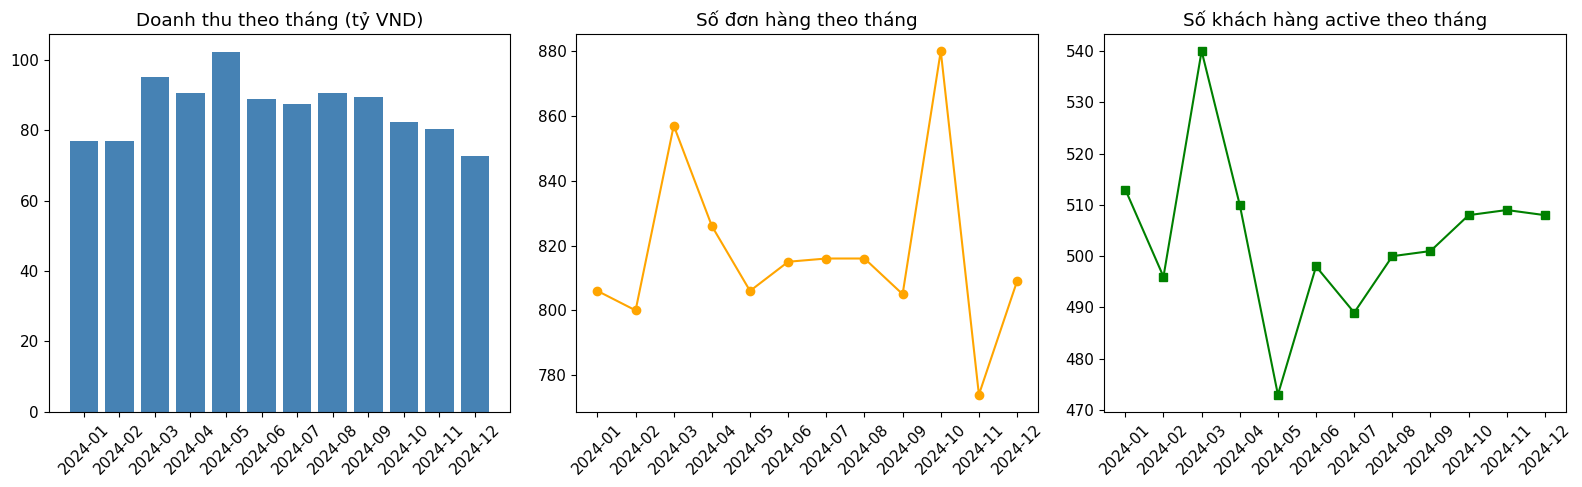

In [ ]:
## 3. Doanh thu theo tháng
monthly = df[df['Doanh_thu'] > 0].groupby('Tháng').agg(
    Doanh_thu   = ('Doanh_thu', 'sum'),
    Số_đơn      = ('Đơn hàng', 'nunique'),
    Số_khách    = ('Mã_KH', 'nunique'),
).reset_index()
monthly['Tháng_str'] = monthly['Tháng'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(monthly['Tháng_str'], monthly['Doanh_thu'] / 1e9, color='steelblue')
axes[0].set_title('Doanh thu theo tháng (tỷ VND)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['Tháng_str'], monthly['Số_đơn'], marker='o', color='orange')
axes[1].set_title('Số đơn hàng theo tháng')
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(monthly['Tháng_str'], monthly['Số_khách'], marker='s', color='green')
axes[2].set_title('Số khách hàng active theo tháng')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

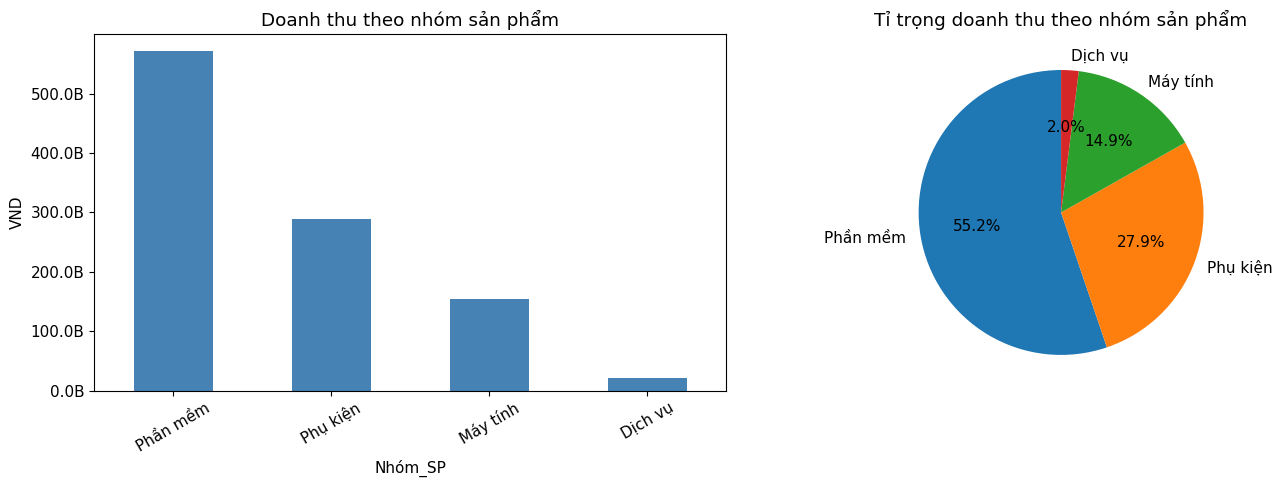

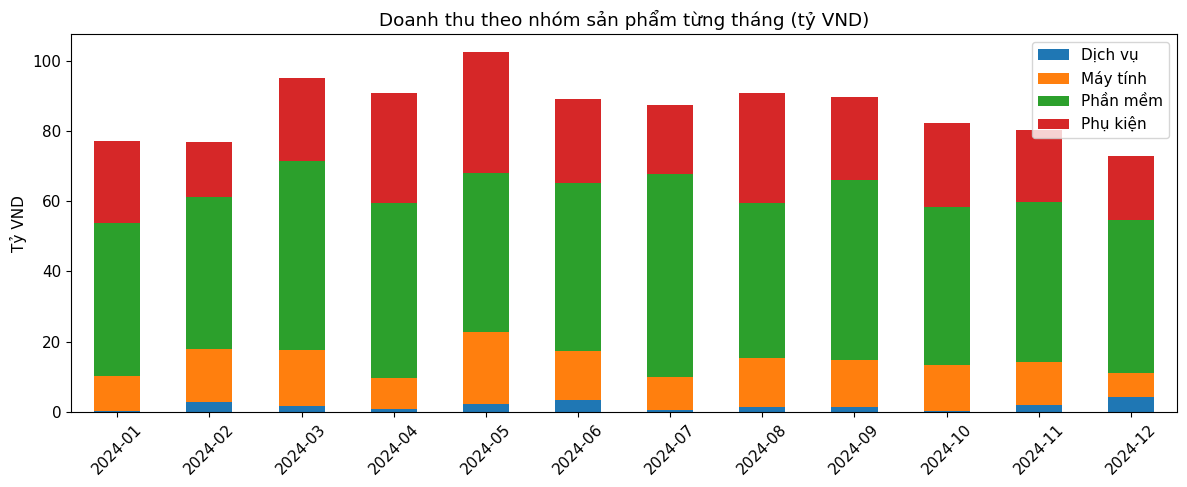

In [ ]:
## 4. Doanh thu theo nhóm sản phẩm
df_clean = df[df['Doanh_thu'] > 0]

by_group = df_clean.groupby('Nhóm_SP')['Doanh_thu'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_group.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Doanh thu theo nhóm sản phẩm')
axes[0].set_ylabel('VND')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

axes[1].pie(by_group, labels=by_group.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỉ trọng doanh thu theo nhóm sản phẩm')

plt.tight_layout()
plt.show()

# Doanh thu từng nhóm theo tháng
monthly_group = df_clean.groupby(['Tháng', 'Nhóm_SP'])['Doanh_thu'].sum().unstack(fill_value=0)
monthly_group.index = monthly_group.index.astype(str)
monthly_group.div(1e9).plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Doanh thu theo nhóm sản phẩm từng tháng (tỷ VND)')
plt.xlabel('')
plt.ylabel('Tỷ VND')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

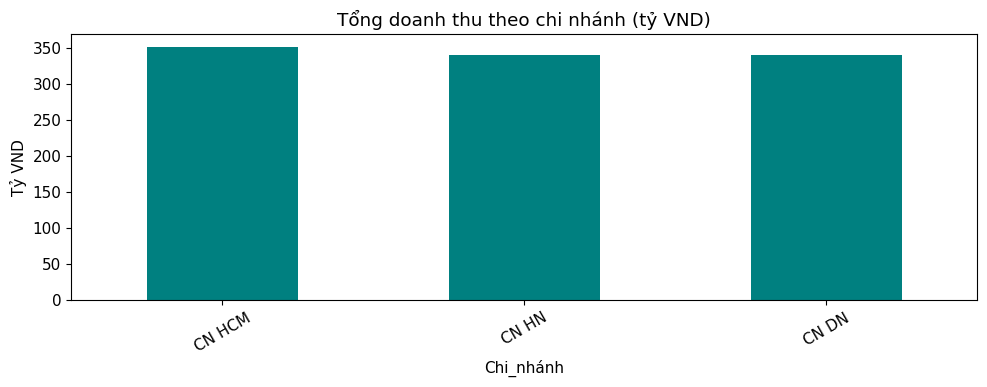

=== KPI Achievement Rate (%) ===
Mã chi nhánh  CN DN  CN HCM  CN HN
YearMonth                         
2024-01       102.9    95.1  110.0
2024-02        94.9    97.8   96.0
2024-03        97.5   101.5  101.0
2024-04        97.3   102.7  102.6
2024-05       100.3    95.0   95.8
2024-06       104.2    99.3   94.6
2024-07        95.2    94.5  101.4
2024-08       104.2    93.8  106.4
2024-09       103.2    99.3   96.8
2024-10        94.0   109.5  110.2
2024-11       101.0   101.0   98.9
2024-12        94.9   101.1   96.0


In [ ]:
## 5. Doanh thu theo chi nhánh & KPI
by_branch = df_clean.groupby('Chi_nhánh')['Doanh_thu'].sum().sort_values(ascending=False)
by_branch.div(1e9).plot(kind='bar', color='teal', figsize=(10, 4))
plt.title('Tổng doanh thu theo chi nhánh (tỷ VND)')
plt.ylabel('Tỷ VND')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# KPI vs Thực tế
kpi['YearMonth'] = kpi['YearMonth'].astype(str)
actual = df_clean.copy()
actual['YearMonth'] = actual['Tháng'].astype(str)
actual_branch = actual.groupby(['YearMonth', 'Chi_nhánh'])['Doanh_thu'].sum().reset_index()
actual_branch.columns = ['YearMonth', 'Mã chi nhánh', 'Actual']

kpi_merge = kpi.merge(actual_branch, on=['YearMonth', 'Mã chi nhánh'], how='left')
kpi_merge['Achievement'] = (kpi_merge['Actual'] / kpi_merge['KPI'] * 100).round(1)

print('=== KPI Achievement Rate (%) ===')
pivot_kpi = kpi_merge.pivot(index='YearMonth', columns='Mã chi nhánh', values='Achievement')
print(pivot_kpi.to_string())

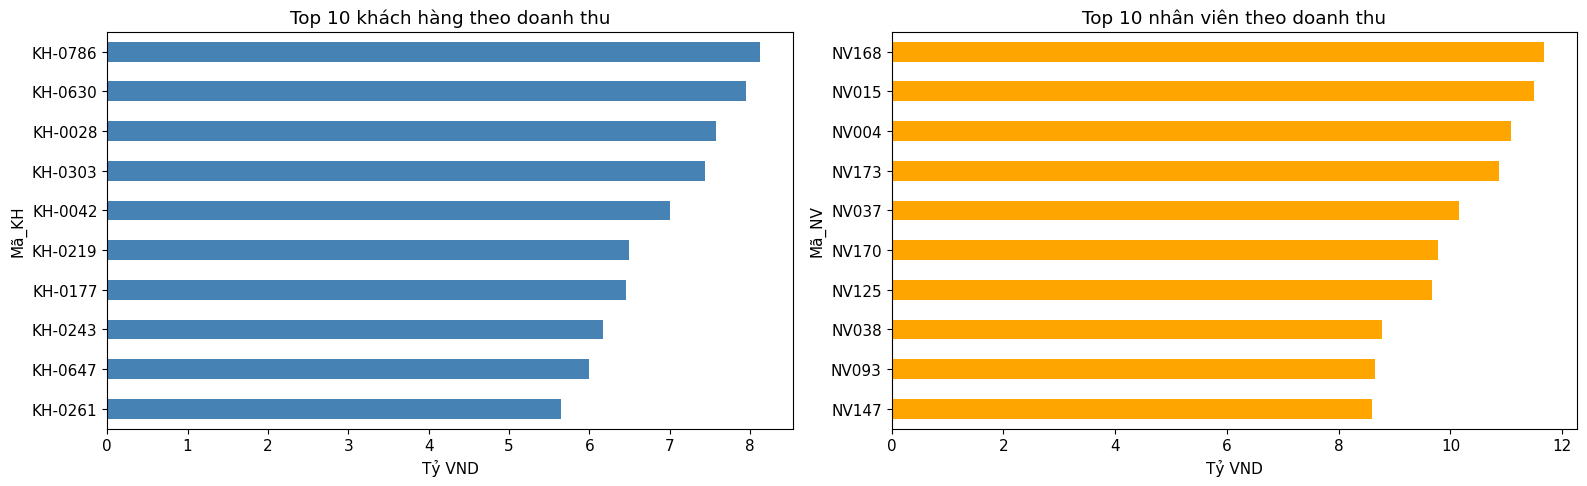

In [ ]:
## 6. Top khách hàng & nhân viên
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 khách hàng
top_kh = df_clean.groupby('Mã_KH')['Doanh_thu'].sum().nlargest(10)
top_kh.div(1e9).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 khách hàng theo doanh thu')
axes[0].set_xlabel('Tỷ VND')
axes[0].invert_yaxis()

# Top 10 nhân viên
top_nv = df_clean.groupby('Mã_NV')['Doanh_thu'].sum().nlargest(10)
top_nv.div(1e9).plot(kind='barh', ax=axes[1], color='orange')
axes[1].set_title('Top 10 nhân viên theo doanh thu')
axes[1].set_xlabel('Tỷ VND')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

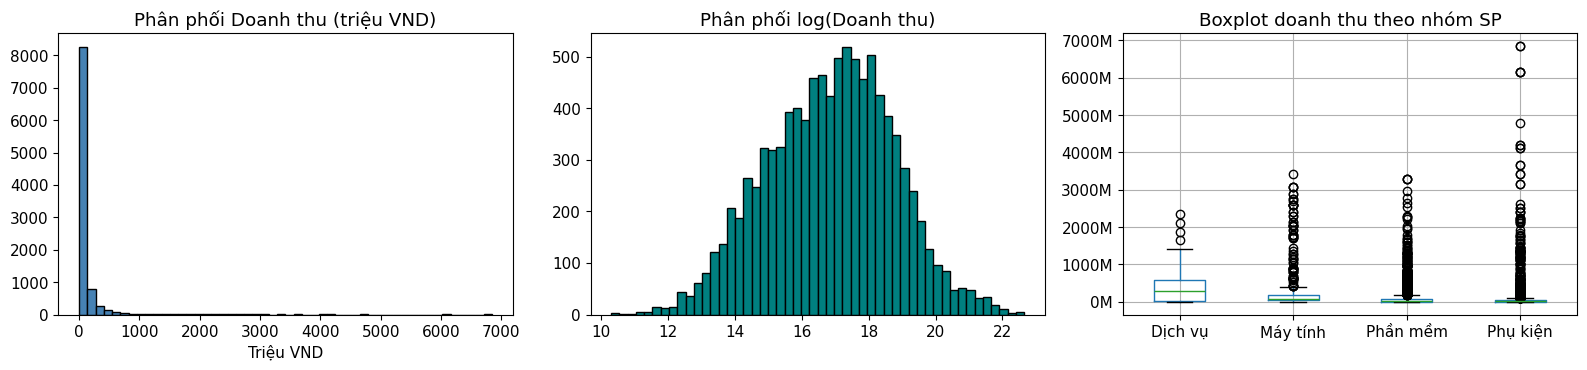

=== Thống kê doanh thu ===
count            9,810
mean       105,416,703
std        323,702,763
min             30,000
25%          5,497,500
50%         23,212,500
75%         79,350,000
max      6,844,500,000
Name: Doanh_thu, dtype: str


In [ ]:
## 7. Phân phối doanh thu & phát hiện outliers
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram doanh thu
axes[0].hist(df_clean['Doanh_thu'] / 1e6, bins=50, color='steelblue', edgecolor='k')
axes[0].set_title('Phân phối Doanh thu (triệu VND)')
axes[0].set_xlabel('Triệu VND')

# Log scale
axes[1].hist(np.log1p(df_clean['Doanh_thu']), bins=50, color='teal', edgecolor='k')
axes[1].set_title('Phân phối log(Doanh thu)')

# Boxplot theo nhóm sản phẩm
df_clean.boxplot(column='Doanh_thu', by='Nhóm_SP', ax=axes[2])
axes[2].set_title('Boxplot doanh thu theo nhóm SP')
axes[2].set_xlabel('')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.suptitle('')

plt.tight_layout()
plt.show()

print('=== Thống kê doanh thu ===')
print(df_clean['Doanh_thu'].describe().apply(lambda x: f'{x:,.0f}'))